In [2]:
# install dependencies (run for the first time only)
# !pip install pandas numpy matplotlib seaborn scikit-learn statsmodels

## **`Data cleaning`**

In [3]:
# import dependencies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler

In [4]:
# load data

df = pd.read_csv('D:/PythonCode/DSEB65A_MachineLearningProject_Group5/data/Hanoi Daily 10 years.csv')


## **`Handling missing values for time-series problem`**

In [5]:
# handling Missing Values

def check_missing_values(df):
    """Return missing percentage for each column."""
    missing = df.isnull().mean() * 100
    return missing[missing > 0].sort_values(ascending=False)

missing_ratio = check_missing_values(df)
print("\nMissing Value Ratio (%):")
print(missing_ratio)

# focus on specific columns
if 'severerisk' in df.columns:
    print(f"\nsevererisk missing: {missing_ratio['severerisk']:.2f}%")
if 'preciptype' in df.columns:
    print(f"preciptype missing: {missing_ratio['preciptype']:.2f}%")


Missing Value Ratio (%):
severerisk    72.677596
preciptype    26.967213
dtype: float64

severerisk missing: 72.68%
preciptype missing: 26.97%


## **`Dropping redundant and zero-variance cols`**

In [6]:
# Constant and Zero-Variance Columns

def find_constant_columns(df):
    """Find columns with only one unique (non-null) value."""
    # This also finds numeric columns with zero variance
    return [col for col in df.columns if df[col].nunique(dropna=True) <= 1]

# find all constant columns
constant_cols = find_constant_columns(df)
print("\nConstant or Zero-Variance Columns Detected:")
print(constant_cols)

# (domain knowledge) other potential cols that should be dropped for future refactor
other_cols_to_drop = ['address', 'resolvedAddress', 'source', 'latitude', 'longitude', 'severerisk', 'stations']

# combine the lists and remove duplicates -> use set
all_cols_to_drop = list(set(constant_cols + other_cols_to_drop))

print("\nFull list of columns to be dropped:")
print(all_cols_to_drop)

# 4. drop the columns that actually exist in the dataframe
# PLEASE note that from now on we only process with cleaned_df for better later debugging
cleaned_df = df.drop(columns=[c for c in all_cols_to_drop if c in df.columns], errors='ignore')


Constant or Zero-Variance Columns Detected:
['name', 'preciptype', 'snow', 'snowdepth']

Full list of columns to be dropped:
['snowdepth', 'snow', 'source', 'longitude', 'address', 'name', 'severerisk', 'stations', 'latitude', 'resolvedAddress', 'preciptype']


In [7]:
# call check_missing_values() again for validation
remaining_missing = check_missing_values(cleaned_df)
if(remaining_missing.empty):
    print("\nNo more missing values")
else:
    print("\nRemaining Missing Value Ratio (%):")
    print(remaining_missing)


No more missing values


## **`Correcting Data Types`**

##### **Converting to timestamp datatype for time-series analysis**

In [8]:
# convert to timestamp data type
cleaned_df['datetime'] = pd.to_datetime(cleaned_df['datetime'])
cleaned_df['sunrise'] = pd.to_datetime(cleaned_df['sunrise'])
cleaned_df['sunset'] = pd.to_datetime(cleaned_df['sunset'])

In [9]:
# multi-label cols processing
# split 'condition' col into binary cols (sep=',')
conditions_dummies = cleaned_df['conditions'].str.get_dummies(sep=', ')

# concat to the processing dataframe
cleaned_df = pd.concat([cleaned_df, conditions_dummies], axis=1)

# now the original
cleaned_df.drop('conditions', axis=1, inplace=True)

# we can and must also drop df['description'],
# because it is just the more complicated version of df['condition'] which we have already handled
cleaned_df.drop('description', axis=1, inplace=True)

##### **One-hot Encoding**

The `icon` column is of object type and needs to be transformed into a numeric format for machine learning models. To do this, we apply **One-Hot Encoding**, a technique that converts categorical data into binary vectors.

This transformation ensures the model can process the data numerically and treat each icon category as a separate feature.


In [10]:
# apply one-hot encoding
icon_dummies = pd.get_dummies(cleaned_df['icon'], prefix='icon')

# concat
cleaned_df = pd.concat([cleaned_df, icon_dummies], axis=1)

# drop orignal one
cleaned_df.drop('icon', axis=1, inplace=True)

## **`Main: Feature Engineering`**

In [11]:
"""
##### **main things to do in this section:**
###### feature extraction:
1. date/time decomposition
4. holiday/season indicators (binary)
2. lag features
3. rolling window stats
6. seasonal decomposition
8. interaction terms
9. external regressors + auto regressive features
###### feature transformation:
5. cyclical encoding (sin/cos)
7. fourier transformation (seasonality)
"""

'\n##### **main things to do in this section:**\n###### feature extraction:\n1. date/time decomposition\n4. holiday/season indicators (binary)\n2. lag features\n3. rolling window stats\n6. seasonal decomposition\n8. interaction terms\n9. external regressors + auto regressive features\n###### feature transformation:\n5. cyclical encoding (sin/cos)\n7. fourier transformation (seasonality)\n'

### **feature extraction**

1. **`date/time decomposition`**

In [12]:
# ADJUSTED

# Các thành phần thời gian cơ bản (Decomposition)
cleaned_df['month'] = cleaned_df['datetime'].dt.month
cleaned_df['day_of_year'] = cleaned_df['datetime'].dt.dayofyear
cleaned_df['day_of_week'] = cleaned_df['datetime'].dt.dayofweek
cleaned_df['week_of_year'] = cleaned_df['datetime'].dt.isocalendar().week.astype(int)
cleaned_df['year'] = cleaned_df['datetime'].dt.year
cleaned_df['quarter'] = cleaned_df['datetime'].dt.quarter  # quarter
cleaned_df['day_of_month'] = cleaned_df['datetime'].dt.day  # day of month
cleaned_df['is_weekend'] = cleaned_df['day_of_week'].isin([5, 6]).astype(int)  # binary

# Daylight duration (Domain-specific decomposition)
cleaned_df['daylight_duration_sec'] = (cleaned_df['sunset'] - cleaned_df['sunrise']).dt.total_seconds()
cleaned_df['daylight_duration_sec'].fillna(0, inplace=True)  # handle NaN

# Feature mùa và mã hóa one-hot (Season Indicators)
def get_season(month):
    if month in [12, 1, 2]: return 'Winter'
    elif month in [3, 4, 5]: return 'Spring'
    elif month in [6, 7, 8]: return 'Summer'
    else: return 'Fall'
cleaned_df['season'] = cleaned_df['month'].apply(get_season)
season_dummies = pd.get_dummies(cleaned_df['season'], prefix='season')
cleaned_df = pd.concat([cleaned_df, season_dummies], axis=1)

C:\Users\Huy\AppData\Local\Temp\ipykernel_14696\1302143445.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  cleaned_df['daylight_duration_sec'].fillna(0, inplace=True)  # handle NaN


2. **`holidays/seasons indicators`**

In [13]:
# NEW

import holidays

# Thêm holiday indicators (Binary cho holiday)
# cho nay dung holidays.VN de trich xuat cac ngay le o vn
vn_holidays = holidays.VN(years=range(cleaned_df['year'].min(), cleaned_df['year'].max() + 1))
cleaned_df['is_holiday'] = cleaned_df['datetime'].apply(lambda x: 1 if x in vn_holidays else 0)

#### 5. **`seasonal decomposition`**

In [14]:
import pandas as pd
import numpy as np
from statsmodels.tsa.seasonal import STL
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf  # Để check resid

# Đảm bảo index là datetime và sorted (tích hợp từ code mới)
if 'datetime' in cleaned_df.columns:
    cleaned_df['datetime'] = pd.to_datetime(cleaned_df['datetime'])
    cleaned_df.set_index('datetime', inplace=True)
cleaned_df.sort_index(inplace=True)  # sort

# Chọn target, handle NaN ban đầu
series_to_decompose = cleaned_df['temp'].dropna()  # Hoặc fill nếu cần: .fillna(method='ffill')

# STL yearly
stl_yearly = STL(series_to_decompose, period=365, seasonal=13, robust=True)
result_yearly = stl_yearly.fit()


##### **concat vào dataset**

In [15]:
# Thêm features vào dataset
cleaned_df['temp_trend_yearly'] = result_yearly.trend
cleaned_df['temp_seasonal_yearly'] = result_yearly.seasonal
cleaned_df['temp_resid_yearly'] = result_yearly.resid

In [16]:
# Handle NaN sau decomposition
print("NaN in new features before handling:")
print(cleaned_df[['temp_trend_yearly', 'temp_seasonal_yearly', 'temp_resid_yearly']].isna().sum())

if cleaned_df[['temp_trend_yearly', 'temp_seasonal_yearly', 'temp_resid_yearly']].isna().any().any():
    # Forward/backward fill để giữ tính liên tục time series
    cleaned_df[['temp_trend_yearly', 'temp_seasonal_yearly', 'temp_resid_yearly']] = \
        cleaned_df[['temp_trend_yearly', 'temp_seasonal_yearly', 'temp_resid_yearly']].fillna(method='ffill')
    cleaned_df[['temp_trend_yearly', 'temp_seasonal_yearly', 'temp_resid_yearly']] = \
        cleaned_df[['temp_trend_yearly', 'temp_seasonal_yearly', 'temp_resid_yearly']].fillna(method='bfill')

print("NaN after handling:", cleaned_df[['temp_trend_yearly', 'temp_seasonal_yearly', 'temp_resid_yearly']].isna().sum().sum())

# Kiểm tra head
print(cleaned_df[['temp', 'temp_seasonal_yearly', 'temp_trend_yearly', 'temp_resid_yearly']].head())

NaN in new features before handling:
temp_trend_yearly       0
temp_seasonal_yearly    0
temp_resid_yearly       0
dtype: int64
NaN after handling: 0
            temp  temp_seasonal_yearly  temp_trend_yearly  temp_resid_yearly
datetime                                                                    
2015-09-20  29.3              4.610702          24.467468           0.221830
2015-09-21  26.8              3.172797          24.469298          -0.842094
2015-09-22  25.9              3.111623          24.471129          -1.682752
2015-09-23  28.0              3.536615          24.472963          -0.009578
2015-09-24  29.9              4.256419          24.474799           1.168782


### **Derived Features**

#### 3. **`lag features`**

In [17]:
# ADJUSTED

# Lag features
lag_cols = ['temp', 'humidity', 'windspeed', 'cloudcover', 'precip']
lags = [1, 2, 7, 30, 365]

for col in lag_cols:
    for lag in lags:
        cleaned_df[f'{col}_lag_{lag}'] = cleaned_df[col].shift(lag)
    cleaned_df[f'{col}_diff_1'] = cleaned_df[col].diff(periods=1)
    cleaned_df[f'{col}_diff_7'] = cleaned_df[col].diff(periods=7)


#### 4. **`rolling window stast`**

In [18]:
# NEW
from statsmodels.tsa.stattools import pacf

# Rolling: Mở rộng cho tất cả lag_cols, thêm EWMA
windows = [3, 7, 14, 30]
for col in lag_cols:
    for window in windows:
        # Rolling trên past data (shift(1) để tránh leakage)
        shifted = cleaned_df[col].shift(1)
        cleaned_df[f'{col}_roll_mean_{window}'] = shifted.rolling(window=window, min_periods=1).mean()
        cleaned_df[f'{col}_roll_std_{window}'] = shifted.rolling(window=window, min_periods=1).std()

        # Thêm min/max/sum cho các cột phù hợp
        if col in ['temp', 'precip', 'windspeed']:
            cleaned_df[f'{col}_roll_min_{window}'] = shifted.rolling(window=window, min_periods=1).min()
            cleaned_df[f'{col}_roll_max_{window}'] = shifted.rolling(window=window, min_periods=1).max()
        if col == 'precip':
            cleaned_df[f'{col}_roll_sum_{window}'] = shifted.rolling(window=window, min_periods=1).sum()

# EWMA
for col in lag_cols:
    cleaned_df[f'{col}_ewm_7'] = cleaned_df[col].shift(1).ewm(span=7, adjust=False).mean()
    cleaned_df[f'{col}_ewm_30'] = cleaned_df[col].shift(1).ewm(span=30, adjust=False).mean()

C:\Users\Huy\AppData\Local\Temp\ipykernel_14696\3597842428.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  cleaned_df[f'{col}_roll_mean_{window}'] = shifted.rolling(window=window, min_periods=1).mean()
C:\Users\Huy\AppData\Local\Temp\ipykernel_14696\3597842428.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  cleaned_df[f'{col}_roll_std_{window}'] = shifted.rolling(window=window, min_periods=1).std()
C:\Users\Huy\AppData\Local\Temp\ipykernel_14696\3597842428.py:10: PerformanceWarning: DataFrame is highly fragmented.  Thi

#### **xử lý lags**

In [19]:
# Chỉ giữ lại các lags có PACF vượt CI ±1.96/√n
from statsmodels.tsa.stattools import pacf

# Hàm chọn lags dựa trên PACF
def select_lags_based_on_pacf(series, max_lags=365, threshold=None):  # Tăng max_lags
    series_clean = series.dropna()
    if threshold is None and len(series_clean) > 0:
        threshold = 1.96 / np.sqrt(len(series_clean))
    pacf_values = pacf(series_clean, nlags=max_lags, alpha=None)
    significant_lags = [lag for lag in range(1, len(pacf_values)) if abs(pacf_values[lag]) > threshold]
    return significant_lags[:5] if len(significant_lags) > 5 else significant_lags

# Áp dụng PACF
initial_lags = [1, 2, 7, 30, 365]
selected_lags = {}
discarded_lags = {}

for col in lag_cols:
    series = cleaned_df[col]
    lags = select_lags_based_on_pacf(series)
    selected_lags[col] = lags
    discarded_lags[col] = [lag for lag in initial_lags if lag not in lags]
    print(f"\nColumn: {col}")
    print(f"Significant lags kept: {selected_lags[col]}")
    print(f"Discarded lags: {discarded_lags[col]}")

# Tạo lại lag features
cleaned_df_adjusted = cleaned_df.copy()
for col in lag_cols:
    current_cols = [c for c in cleaned_df.columns if c.startswith(f'{col}_lag_')]
    cleaned_df_adjusted.drop(columns=current_cols, inplace=True)
    if selected_lags[col]:
        for lag in selected_lags[col]:
            cleaned_df_adjusted[f'{col}_lag_{lag}'] = cleaned_df[col].shift(lag)
    else:
        print(f"No significant lags for {col}, keeping original column.")


Column: temp
Significant lags kept: [1, 2, 3, 4, 5]
Discarded lags: [7, 30, 365]

Column: humidity
Significant lags kept: [1, 2, 3, 4, 9]
Discarded lags: [7, 30, 365]

Column: windspeed
Significant lags kept: [1, 3, 7, 8, 9]
Discarded lags: [2, 30, 365]

Column: cloudcover
Significant lags kept: [1, 2, 3, 4, 6]
Discarded lags: [7, 30, 365]

Column: precip
Significant lags kept: [1, 2, 3, 4, 5]
Discarded lags: [7, 30, 365]


##### **=>Ở đây có nhận xét rằng có vẻ đã đi đúng hướng vì bước trên chỉ ra residual vẫn còn chứa tương quan ngắn hạn.**

In [20]:
# Xử lý NaN
cleaned_df_adjusted.fillna(method='bfill', inplace=True)  # Chọn bfill hoặc ffill

# Gán lại dữ liệu
cleaned_df = cleaned_df_adjusted

C:\Users\Huy\AppData\Local\Temp\ipykernel_14696\541126571.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  cleaned_df_adjusted.fillna(method='bfill', inplace=True)  # Chọn bfill hoặc ffill


#### 6. **`feature Interactions`**

In [21]:
# NEW

# Hiệu ứng của nhiệt độ 1 ngày trước trong mùa hè
cleaned_df['interaction_lag1_summer'] = cleaned_df['temp_lag_1'] * cleaned_df['season_Summer']

# Hiệu ứng của nhiệt độ 1 ngày trước vào cuối tuần
cleaned_df['interaction_lag1_weekend'] = cleaned_df['temp_lag_1'] * cleaned_df['is_weekend']

# "Hiệu ứng gió lạnh" = tốc độ gió * (mức độ quang đãng của bầu trời)
cleaned_df['interaction_wind_clearsky_effect'] = cleaned_df['windspeed'] * (1 - cleaned_df['cloudcover'] / 100.0)

# Bức xạ hiệu dụng (Effective Solar Radiation)
cleaned_df['effective_radiation'] = cleaned_df['solarradiation'] * (1 - cleaned_df['cloudcover'] / 100)

# Tương tác giữa Độ ẩm và Nhiệt độ
cleaned_df['humidity_temp_interact'] = cleaned_df['humidity'] * cleaned_df['temp']

In [22]:
# Validation
columns_to_show = [
    'temp_lag_1', 'season_Summer', 'interaction_lag1_summer',  # Thay temp_lag_7 bằng temp_lag_1
    'is_weekend', 'interaction_lag1_weekend',  # Thay temp_lag_7 bằng temp_lag_1
    'windspeed', 'cloudcover', 'interaction_wind_clearsky_effect'
]
print(cleaned_df[columns_to_show].head(10))

# In ra danh sách các cột cuối cùng
print("\nCác cột cuối cùng trong DataFrame:")
print(cleaned_df.columns[-5:])

            temp_lag_1  season_Summer  interaction_lag1_summer  is_weekend  \
datetime                                                                     
2015-09-20        29.3          False                      0.0           1   
2015-09-21        29.3          False                      0.0           0   
2015-09-22        26.8          False                      0.0           0   
2015-09-23        25.9          False                      0.0           0   
2015-09-24        28.0          False                      0.0           0   
2015-09-25        29.9          False                      0.0           0   
2015-09-26        30.5          False                      0.0           1   
2015-09-27        28.6          False                      0.0           1   
2015-09-28        29.6          False                      0.0           0   
2015-09-29        30.3          False                      0.0           0   

            interaction_lag1_weekend  windspeed  cloudcover  \


#### 6. **`domain-specific features`**

In [23]:
# Biên độ nhiệt trong ngày
cleaned_df['temp_range'] = cleaned_df['tempmax'] - cleaned_df['tempmin']

# Độ bão hòa hơi nước
cleaned_df['dew_point_depression'] = cleaned_df['temp'] - cleaned_df['dew']

### **`Feature transformation`**

#### 1. **`cyclical encoding`**

In [24]:
# NEW
# cyclical encoding
cleaned_df['day_of_year'] = cleaned_df.index.dayofyear
cleaned_df['sin_day_of_year'] = np.sin(2 * np.pi * cleaned_df['day_of_year'] / 365)
cleaned_df['cos_day_of_year'] = np.cos(2 * np.pi * cleaned_df['day_of_year'] / 365)

# same to hour_of_day
if cleaned_df.index.freq == 'H' or cleaned_df.index.freq == 'h':
    cleaned_df['hour_of_day'] = cleaned_df.index.hour
    cleaned_df['sin_hour_of_day'] = np.sin(2 * np.pi * cleaned_df['hour_of_day'] / 24)
    cleaned_df['cos_hour_of_day'] = np.cos(2 * np.pi * cleaned_df['hour_of_day'] / 24)

# Xử lý NaN
cleaned_df.fillna(method='bfill', inplace=True)
cleaned_df.fillna(method='ffill', inplace=True)

C:\Users\Huy\AppData\Local\Temp\ipykernel_14696\1082448005.py:14: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  cleaned_df.fillna(method='bfill', inplace=True)
C:\Users\Huy\AppData\Local\Temp\ipykernel_14696\1082448005.py:15: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  cleaned_df.fillna(method='ffill', inplace=True)


In [25]:
# Mã hóa hướng gió (0-360 độ)
cleaned_df['winddir_sin'] = np.sin(np.deg2rad(cleaned_df['winddir']))
cleaned_df['winddir_cos'] = np.cos(np.deg2rad(cleaned_df['winddir']))

# Mã hóa pha mặt trăng (0-1)
cleaned_df['moonphase_sin'] = np.sin(2 * np.pi * cleaned_df['moonphase'])
cleaned_df['moonphase_cos'] = np.cos(2 * np.pi * cleaned_df['moonphase'])

#### 2. **`Vector transformation`**

In [26]:
# Vector gió (sử dụng các cột sin/cos đã tạo)
cleaned_df['wind_vector_ns'] = cleaned_df['windspeed'] * cleaned_df['winddir_cos']
cleaned_df['wind_vector_ew'] = cleaned_df['windspeed'] * cleaned_df['winddir_sin']

#### 3. **`Fourier transformation`**

In [27]:
from scipy.fft import fft, fftfreq  # Thêm cho FFT

residual = result_yearly.resid.dropna().values  # Residual từ STL
n = len(residual)  # Độ dài chuỗi

# Tính FFT trên residual
fft_values = fft(residual)
frequencies = fftfreq(n)

# Lấy biên độ và chọn top 3 tần số (bỏ freq=0)
amplitudes = np.abs(fft_values)
top_freq_indices = np.argsort(amplitudes)[::-1][1:4]  # Top 3
top_frequencies = frequencies[top_freq_indices]

# Tạo feature sin/cos từ top frequencies
t = np.arange(n)  # Thời gian index
for i, freq in enumerate(top_frequencies):
    cleaned_df[f'fft_sin_freq_{i+1}'] = np.sin(2 * np.pi * freq * t)
    cleaned_df[f'fft_cos_freq_{i+1}'] = np.cos(2 * np.pi * freq * t)

# Xử lý NaN nếu có
cleaned_df.fillna(method='bfill', inplace=True)
cleaned_df.fillna(method='ffill', inplace=True)

# Kiểm tra kết quả
print("Top frequencies:", top_frequencies)
print("Chu kỳ tương ứng:", 1 / top_frequencies[top_frequencies != 0])



# In head của feature mới
new_columns = [col for col in cleaned_df.columns if 'fft' in col]


Top frequencies: [-0.01530055  0.01229508 -0.01229508]
Chu kỳ tương ứng: [-65.35714286  81.33333333 -81.33333333]


C:\Users\Huy\AppData\Local\Temp\ipykernel_14696\1620753895.py:22: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  cleaned_df.fillna(method='bfill', inplace=True)
C:\Users\Huy\AppData\Local\Temp\ipykernel_14696\1620753895.py:23: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  cleaned_df.fillna(method='ffill', inplace=True)


In [28]:
# Danh sách các cột gốc cần xóa vì thông tin đã được chuyển hóa
cols_to_drop = [
    'datetime', 'sunrise', 'sunset', # Đã khai thác
    'winddir', 'moonphase',         # Đã mã hóa
    'season',                       # Đã mã hóa one-hot
    'name', 'stations', 'description', 'preciptype', 'icon', 'conditions', # Cột không cần thiết
    'severerisk', # Có quá nhiều giá trị thiếu
    'feelslike',
    'feelslikemax',
    'feelslikemin',
]

# Chỉ xóa các cột thực sự tồn tại
existing_cols_to_drop = [col for col in cols_to_drop if col in cleaned_df.columns]
cleaned_df.drop(columns=existing_cols_to_drop, inplace=True)
print(f"   - Dropped {len(existing_cols_to_drop)} unnecessary columns.")

# Xóa tất cả các dòng có NaN (chủ yếu do lag và rolling)
initial_rows = len(cleaned_df)
cleaned_df.dropna(inplace=True)
final_rows = len(cleaned_df)
print(f"   - Dropped {initial_rows - final_rows} rows with NaN values.")


   - Dropped 8 unnecessary columns.
   - Dropped 0 rows with NaN values.


In [29]:
cleaned_df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3660 entries, 2015-09-20 to 2025-09-26
Columns: 175 entries, tempmax to fft_cos_freq_3
dtypes: bool(8), float64(152), int32(6), int64(9)
memory usage: 4.6 MB


#### 76 features are...
-> Lets go do some correlation analysis

### **`Correlation analysis`**

In [30]:
# Select numeric columns
num_df = cleaned_df.select_dtypes(include=[np.number])

# Compute Pearson correlation
corr_matrix = num_df.corr()

# Visualization function
def plot_correlation_heatmap(correlation_matrix, figsize=(20, 15), annot=False, title="Correlation Matrix"):
    """
    Vẽ heatmap tương quan. Mặc định tắt annot để dễ nhìn hơn với ma trận lớn.
    """
    mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
    plt.figure(figsize=figsize)
    sns.heatmap(correlation_matrix,
                mask=mask,          # Luôn áp dụng mask
                cmap='coolwarm',
                center=0,
                annot=annot,        # Tùy chọn bật/tắt giá trị
                fmt=".2f",
                linewidths=.5)
    plt.title(title, fontsize=16)
    plt.tight_layout()
    plt.show()

# # call function
# plot_correlation_heatmap(corr_matrix, annot=False, title="Tổng Quan Tương Quan Giữa Các Feature")


In [31]:
# Sort top correlations with temp
top_corr = corr_matrix['temp'].abs().sort_values(ascending=False).head(40)
print("\nTop 40 Features Correlated with 'temp':")
print(top_corr)


Top 40 Features Correlated with 'temp':
temp                       1.000000
tempmax                    0.977442
tempmin                    0.969415
temp_lag_1                 0.945100
temp_roll_min_3            0.911240
temp_roll_mean_3           0.905517
temp_ewm_7                 0.905007
dew                        0.903089
temp_seasonal_yearly       0.891597
temp_roll_max_3            0.881554
temp_roll_min_7            0.878219
temp_roll_mean_7           0.874797
temp_lag_2                 0.874399
sealevelpressure           0.867498
temp_roll_mean_14          0.865161
temp_roll_min_14           0.859489
humidity_temp_interact     0.857033
temp_ewm_30                0.853705
temp_roll_max_7            0.845163
temp_roll_mean_30          0.837413
temp_roll_max_14           0.833321
temp_lag_3                 0.825089
temp_roll_min_30           0.816328
cos_day_of_year            0.816123
temp_roll_max_30           0.810949
temp_lag_4                 0.795902
temp_lag_5             

In [32]:
# Handling multicolinearity

def find_highly_correlated_features(corr_matrix, threshold=0.95):
    """
    Find feature pairs with correlation above the specified threshold.
    """
    # Get the upper triangle of the correlation matrix
    upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

    # Find feature pairs with correlation > threshold
    highly_correlated_pairs = [
        (column, upper_tri[column].abs().idxmax(), upper_tri[column].abs().max())
        for column in upper_tri.columns if upper_tri[column].abs().max() > threshold
    ]

    # Sort for easier viewing
    sorted_pairs = sorted(highly_correlated_pairs, key=lambda x: x[2], reverse=True)

    return sorted_pairs


def drop_correlated_features(df, correlated_pairs, target_col):
    """
    Drop one feature from each highly correlated pair.
    This function keeps the feature that has higher correlation with the target variable.
    Args:
        df (pd.DataFrame): The DataFrame containing the data.
        correlated_pairs (list): List of highly correlated feature pairs from the find_highly_correlated_features function.
        target_col (str): The name of the target column (e.g., 'temp').
    Returns:
        pd.DataFrame: The new DataFrame with features dropped.
        set: A set of dropped columns.
    """
    cols_to_drop = set()

    # Calculate correlation of all features with the target column once
    corr_with_target = df.corr()[target_col].abs()

    # Iterate through the pairs found
    for feat1, feat2, _ in correlated_pairs:
        # Get the correlation values with the target for each feature in the pair
        corr1 = corr_with_target.get(feat1, 0)
        corr2 = corr_with_target.get(feat2, 0)

        # Decide which feature to drop
        if corr1 > corr2:
            # Keep feat1, drop feat2
            cols_to_drop.add(feat2)
        else:
            # Keep feat2, drop feat1
            cols_to_drop.add(feat1)

    # Drop the identified columns
    df_reduced = df.drop(columns=list(cols_to_drop))

    print(f"\nDropped {len(cols_to_drop)} features due to multicollinearity.")
    if cols_to_drop:
        print("- Dropped columns:", list(cols_to_drop))

    return df_reduced, cols_to_drop

In [33]:
correlated_pairs = find_highly_correlated_features(corr_matrix, threshold=0.70)

print("\n feature pairs with very high correlation (> 0.70):")
for feat1, feat2, corr_val in correlated_pairs:
    print(f"- {feat1:<25} and {feat2:<25} : {corr_val:.4f}")

df_final, dropped_cols = drop_correlated_features(df=cleaned_df,
                                                  correlated_pairs=correlated_pairs,
                                                  target_col='temp')


 feature pairs with very high correlation (> 0.70):
- Rain                      and precipprob                : 1.0000
- fft_sin_freq_3            and fft_sin_freq_2            : 1.0000
- fft_cos_freq_3            and fft_cos_freq_2            : 1.0000
- precip_roll_sum_3         and precip_roll_mean_3        : 1.0000
- solarenergy               and solarradiation            : 0.9999
- precip_roll_sum_7         and precip_roll_mean_7        : 0.9998
- precip_roll_sum_14        and precip_roll_mean_14       : 0.9991
- precip_roll_sum_30        and precip_roll_mean_30       : 0.9975
- precip_roll_max_7         and precip_roll_std_7         : 0.9975
- day_of_year               and month                     : 0.9965
- temp_ewm_30               and temp_roll_mean_30         : 0.9949
- precip_roll_max_14        and precip_roll_std_14        : 0.9936
- precip_roll_max_3         and precip_roll_std_3         : 0.9921
- temp_ewm_7                and temp_roll_mean_7          : 0.9919
- dew_poi

## Label Creating

In [34]:
df_final, dropped_cols = drop_correlated_features(df=cleaned_df,
                                                  correlated_pairs=correlated_pairs,
                                                  target_col='temp')
#Tạo 5 objective feature tương ứng với 5 ngày cần dự đoán
horizons = [1, 2, 3, 4, 5]
for h in horizons:
    df_final[f'target_temp_t+{h}'] = df_final['temp'].shift(-h)
df_final = df_final.dropna()
print(df_final.columns)
print(f"Number of columns in df_final: {df_final.shape[1]}")


Dropped 84 features due to multicollinearity.
- Dropped columns: ['precip_ewm_30', 'windspeed_roll_max_14', 'temp_roll_std_14', 'windspeed_ewm_7', 'windspeed_roll_min_7', 'temp_roll_min_14', 'humidity_roll_mean_7', 'precip_roll_mean_7', 'month', 'cloudcover_roll_mean_30', 'fft_sin_freq_3', 'precip_roll_std_7', 'precip_roll_mean_14', 'cloudcover_roll_mean_7', 'precip_roll_std_14', 'precip_roll_sum_14', 'week_of_year', 'temp_roll_min_3', 'windspeed_roll_mean_14', 'precip_roll_max_30', 'humidity_roll_mean_30', 'sealevelpressure', 'cloudcover_lag_4', 'Overcast', 'precip_roll_sum_30', 'dew_point_depression', 'precip_roll_std_30', 'daylight_duration_sec', 'Rain', 'temp_lag_2', 'humidity_lag_4', 'tempmax', 'temp_roll_mean_3', 'temp_roll_mean_7', 'temp_roll_max_14', 'humidity_lag_1', 'humidity_temp_interact', 'precip_roll_std_3', 'precip_lag_2', 'windspeed_roll_max_7', 'temp_lag_5', 'humidity_lag_2', 'precip_roll_sum_3', 'windspeed_roll_std_30', 'windspeed_roll_mean_3', 'humidity_roll_mean_14

## Data Spliting
- Tập train 70%, tập valid 15%, tập test 15%

In [35]:
from sklearn.model_selection import train_test_split

# Giả sử df_final là DataFrame của bạn trước khi split
X = df_final.drop([f'target_temp_t+{h}' for h in horizons], axis=1)
y = df_final[[f'target_temp_t+{h}' for h in horizons]]

# Split the data into train (70%) and temp (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, shuffle=False
)
# Split the temp data into validation (15%) and test (15%)
X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, shuffle=False
)

## Feature Selection
- Permutation Importance là phương pháp đánh giá mức độ quan trọng của từng đặc trưng (feature) trong mô hình. Ý tưởng chính là xáo trộn giá trị của một đặc trưng và quan sát mức độ giảm hiệu suất của mô hình. Nếu hiệu suất giảm nhiều, đặc trưng đó quan trọng.

- Cách hoạt động
1. Huấn luyện mô hình: Dùng tập dữ liệu ban đầu.
2. Tính hiệu suất gốc: Đánh giá mô hình trên tập valid (test).
3. Xáo trộn đặc trưng: Ngẫu nhiên xáo trộn giá trị của một cột (feature) và giữ nguyên các cột khác.
4. Đánh giá lại mô hình: Tính hiệu suất sau khi xáo trộn.
5. Tính mức độ quan trọng: Hiệu suất giảm = mức độ quan trọng của đặc trưng.


In [36]:
from catboost import CatBoostRegressor
from sklearn.inspection import permutation_importance
import pandas as pd
import numpy as np
from sklearn.multioutput import MultiOutputRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Huấn luyện mô hình LightGBM
# Tạo pipeline với StandardScaler và LGBMRegressor
pipeline = Pipeline([
    ('scaler', RobustScaler()),
    ('model', MultiOutputRegressor(CatBoostRegressor(random_state=42, verbose=0)))
])
pipeline.fit(X_train, y_train)

# Tính toán Permutation Importance
print("\n--- Đánh giá tầm quan trọng của đặc trưng theo hoán vị (Permutation Importance) ---")
result = permutation_importance(
    pipeline, X_valid, y_valid,
    n_repeats=10,  # Số lần lặp lại việc xáo trộn cho mỗi đặc trưng
    random_state=42,
    n_jobs=-1,  # Sử dụng tất cả các lõi CPU
    scoring='neg_root_mean_squared_error'  # Đánh giá bằng RMSE (phủ định)
)

# Lấy tên đặc trưng
if hasattr(X_test, 'columns'):
    feature_names_pi = X_valid.columns.tolist()
else:
    feature_names_pi = [f"feature_{i}" for i in range(X_valid.shape[1])]

# Tạo DataFrame
permutation_importance_df = pd.DataFrame({
    'Feature': feature_names_pi,
    'Importance_Mean': result.importances_mean,
    'Importance_Std': result.importances_std
})

# Sắp xếp theo tầm quan trọng giảm dần
permutation_importance_df = permutation_importance_df.sort_values(by='Importance_Mean', ascending=False)

# In top 10 đặc trưng quan trọng nhất
print("\nTop 10 đặc trưng quan trọng nhất theo Permutation Importance:")
print(permutation_importance_df.head(10))



--- Đánh giá tầm quan trọng của đặc trưng theo hoán vị (Permutation Importance) ---

Top 10 đặc trưng quan trọng nhất theo Permutation Importance:
            Feature  Importance_Mean  Importance_Std
82  cos_day_of_year         0.925673        0.042246
0              temp         0.705353        0.024863
61      temp_ewm_30         0.256100        0.018434
21    season_Winter         0.164610        0.011440
60       temp_ewm_7         0.152170        0.016428
83      winddir_cos         0.067136        0.009355
25      temp_diff_1         0.034637        0.003981
37  temp_roll_min_7         0.033433        0.005887
8    solarradiation         0.028730        0.002817
5          windgust         0.021372        0.005532


- Có thể điều chỉnh threshold giảm xuống để tăng số feature, tùy theo độ mạnh yếu của từng máy thì hãy chọn số feature phù hợp.

In [45]:
# Lọc các feature dựa trên permutation_importance_df['Feature']
threshold = 0.003
selected_features = permutation_importance_df[permutation_importance_df['Importance_Mean'] > threshold]['Feature'].tolist()
# Tạo X chỉ với các cột được chọn
X_train_permuted = X_train[selected_features]
X_valid_permuted = X_valid[selected_features]
X_test_permuted = X_test[selected_features]

print("Shape of X_train permuted:", X_train_permuted.shape)
print("Shape of X valid permuted", X_valid_permuted.shape)
print("Shape of X_test permuted", X_test_permuted.shape)

Shape of X_train permuted: (2558, 31)
Shape of X valid permuted (548, 31)
Shape of X_test permuted (549, 31)


## Optuna Hyperparam
- Optuna là một framework dùng để tối ưu hóa các siêu tham số của từng mô hình.

In [46]:
import optuna
from lightgbm import LGBMRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
from catboost import CatBoostRegressor

model_for_selection = MultiOutputRegressor(CatBoostRegressor(random_state=42, verbose=0))

def objective(trial):
    """
    Optuna objective: tối ưu siêu tham số cho CatBoostRegressor (MultiOutput).
    """
    param = {
            "iterations": trial.suggest_int("iterations", 100, 3000),
            "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.3, log=True),
            "depth": trial.suggest_int("depth", 4, 10),
            "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1e-3, 10.0, log=True),
            "bagging_temperature": trial.suggest_float("bagging_temperature", 0.0, 1.0),
            "random_strength": trial.suggest_float("random_strength", 1e-3, 10.0, log=True),
            "border_count": trial.suggest_int("border_count", 32, 255),
            "grow_policy": trial.suggest_categorical("grow_policy", ["SymmetricTree", "Depthwise", "Lossguide"]),
            "random_seed": 42,
            "verbose": 0
        }

    model = CatBoostRegressor(**param)

    multi_model = MultiOutputRegressor(model)
    multi_model.fit(X_train_permuted, y_train)

    y_pred = multi_model.predict(X_valid_permuted)

    r2 = r2_score(y_valid, y_pred, multioutput='uniform_average')
    return r2

def print_best_trial(study, trial):
    """
    Callback để in thông tin về trial tốt nhất sau mỗi lần chạy.
    """
    print("\n------------------------------------------------")
    print(f"Trial hiện tại: {trial.number}")
    print(f"  Giá trị R2: {trial.value:.4f}")
    print("Trial tốt nhất hiện tại:")
    print(f"  Giá trị RMSE tốt nhất: {study.best_value:.4f}")
    print("  Các siêu tham số tốt nhất: ")
    for key, value in study.best_params.items():
        print(f"    {key}: {value}")
    print("------------------------------------------------")

# Tạo Optuna study.
study = optuna.create_study(direction="maximize",
                            pruner=optuna.pruners.MedianPruner(n_startup_trials=3, n_warmup_steps=30))

print("Bắt đầu quá trình tối ưu hóa siêu tham số CatBoostRegressor với Optuna...")
study.optimize(objective, n_trials=30, n_jobs=-1, callbacks=[print_best_trial])

# In kết quả tốt nhất tìm được.
print("\n------------------------------------------------")
print("Kết quả tối ưu hóa hoàn tất.")
print("Trial tốt nhất:")
print(f"  Giá trị R2 tốt nhất trên tập validation: {study.best_value:.4f}")
print("  Các siêu tham số tốt nhất: ")
for key, value in study.best_params.items():
    print(f"    {key}: {value}")
print("------------------------------------------------")


d:\PythonCode\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2025-10-27 15:26:44,567] A new study created in memory with name: no-name-604c9995-f4cb-4155-a150-4b084fe32ccd


Bắt đầu quá trình tối ưu hóa siêu tham số CatBoostRegressor với Optuna...


[I 2025-10-27 15:27:01,198] Trial 8 finished with value: 0.7410178696216231 and parameters: {'iterations': 146, 'learning_rate': 0.29207696388902127, 'depth': 4, 'l2_leaf_reg': 0.5145850661515058, 'bagging_temperature': 0.13347793856768841, 'random_strength': 2.547938817496428, 'border_count': 85, 'grow_policy': 'Depthwise'}. Best is trial 8 with value: 0.7410178696216231.



------------------------------------------------
Trial hiện tại: 8
  Giá trị R2: 0.7410
Trial tốt nhất hiện tại:
  Giá trị RMSE tốt nhất: 0.7410
  Các siêu tham số tốt nhất: 
    iterations: 146
    learning_rate: 0.29207696388902127
    depth: 4
    l2_leaf_reg: 0.5145850661515058
    bagging_temperature: 0.13347793856768841
    random_strength: 2.547938817496428
    border_count: 85
    grow_policy: Depthwise
------------------------------------------------


[I 2025-10-27 15:27:22,894] Trial 9 finished with value: 0.7908256933274425 and parameters: {'iterations': 364, 'learning_rate': 0.060550292254507046, 'depth': 4, 'l2_leaf_reg': 0.4695342223503465, 'bagging_temperature': 0.9329440577310119, 'random_strength': 0.40485468083698833, 'border_count': 238, 'grow_policy': 'SymmetricTree'}. Best is trial 9 with value: 0.7908256933274425.


...


------------------------------------------------
Trial hiện tại: 11
  Giá trị R2: 0.7822
Trial tốt nhất hiện tại:
  Giá trị RMSE tốt nhất: 0.7909
  Các siêu tham số tốt nhất: 
    iterations: 2818
    learning_rate: 0.0075313933298081105
    depth: 4
    l2_leaf_reg: 0.8182362190253332
    bagging_temperature: 0.375664213071431
    random_strength: 0.07927389872725706
    border_count: 253
    grow_policy: SymmetricTree
------------------------------------------------


[I 2025-10-27 17:06:36,676] Trial 20 finished with value: 0.7788022069836856 and parameters: {'iterations': 2437, 'learning_rate': 0.0011051242625678406, 'depth': 7, 'l2_leaf_reg': 0.38050943225545625, 'bagging_temperature': 0.614354920049431, 'random_strength': 0.02733997440415931, 'border_count': 42, 'grow_policy': 'Depthwise'}. Best is trial 24 with value: 0.7909281791272528.



------------------------------------------------
Trial hiện tại: 20
  Giá trị R2: 0.7788
Trial tốt nhất hiện tại:
  Giá trị RMSE tốt nhất: 0.7909
  Các siêu tham số tốt nhất: 
    iterations: 2818
    learning_rate: 0.0075313933298081105
    depth: 4
    l2_leaf_reg: 0.8182362190253332
    bagging_temperature: 0.375664213071431
    random_strength: 0.07927389872725706
    border_count: 253
    grow_policy: SymmetricTree
------------------------------------------------


[I 2025-10-27 17:34:34,504] Trial 5 finished with value: 0.7752196597124215 and parameters: {'iterations': 2355, 'learning_rate': 0.001081048099311526, 'depth': 9, 'l2_leaf_reg': 0.011651034484612601, 'bagging_temperature': 0.46364050059812334, 'random_strength': 0.10425417032726908, 'border_count': 183, 'grow_policy': 'Depthwise'}. Best is trial 24 with value: 0.7909281791272528.



------------------------------------------------
Trial hiện tại: 5
  Giá trị R2: 0.7752
Trial tốt nhất hiện tại:
  Giá trị RMSE tốt nhất: 0.7909
  Các siêu tham số tốt nhất: 
    iterations: 2818
    learning_rate: 0.0075313933298081105
    depth: 4
    l2_leaf_reg: 0.8182362190253332
    bagging_temperature: 0.375664213071431
    random_strength: 0.07927389872725706
    border_count: 253
    grow_policy: SymmetricTree
------------------------------------------------

------------------------------------------------
Kết quả tối ưu hóa hoàn tất.
Trial tốt nhất:
  Giá trị R2 tốt nhất trên tập validation: 0.7909
  Các siêu tham số tốt nhất: 
    iterations: 2818
    learning_rate: 0.0075313933298081105
    depth: 4
    l2_leaf_reg: 0.8182362190253332
    bagging_temperature: 0.375664213071431
    random_strength: 0.07927389872725706
    border_count: 253
    grow_policy: SymmetricTree
------------------------------------------------


## Final Test
- Test model tốt nhất trên tập test

In [49]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Huấn luyện lại model với các tham số tốt nhất
best_model = MultiOutputRegressor(CatBoostRegressor(**study.best_params, random_state=42))
best_model.fit(X_train_permuted, y_train)

# Dự đoán trên tập test
y_pred = best_model.predict(X_test_permuted)

# Tính toán các chỉ số đánh giá cho từng label
labels = y_test.columns  # Lấy tên các label
metrics = {}

for i, label in enumerate(labels):
    r2 = r2_score(y_test.iloc[:, i], y_pred[:, i])
    rmse = np.sqrt(mean_squared_error(y_test.iloc[:, i], y_pred[:, i]))
    mae = mean_absolute_error(y_test.iloc[:, i], y_pred[:, i])
    metrics[label] = {"R2": r2, "RMSE": rmse, "MAE": mae}

# In kết quả cho từng label
print("\nĐánh giá trên từng label:")
for label, metric in metrics.items():
    print(f"\nLabel: {label}")
    print(f"  R²: {metric['R2']:.4f}")
    print(f"  RMSE: {metric['RMSE']:.4f}")
    print(f"  MAE: {metric['MAE']:.4f}")
    # Tính toán các chỉ số đánh giá macro
macro_r2 = r2_score(y_test, y_pred, multioutput='uniform_average')
macro_rmse = np.sqrt(mean_squared_error(y_test, y_pred, multioutput='uniform_average'))
macro_mae = mean_absolute_error(y_test, y_pred)

# In kết quả macro
print("\nĐánh giá macro:")
print(f"  Macro R²: {macro_r2:.4f}")
print(f"  Macro RMSE: {macro_rmse:.4f}")
print(f"  Macro MAE: {macro_mae:.4f}")

0:	learn: 5.1115047	total: 3.56ms	remaining: 10s
1:	learn: 5.0792220	total: 6.54ms	remaining: 9.21s
2:	learn: 5.0470396	total: 9.15ms	remaining: 8.58s
3:	learn: 5.0153137	total: 11.5ms	remaining: 8.1s
4:	learn: 4.9837909	total: 14ms	remaining: 7.86s
5:	learn: 4.9523488	total: 15.4ms	remaining: 7.22s
6:	learn: 4.9212152	total: 16.9ms	remaining: 6.77s
7:	learn: 4.8903716	total: 18.6ms	remaining: 6.53s
8:	learn: 4.8601359	total: 20.3ms	remaining: 6.32s
9:	learn: 4.8299920	total: 22.2ms	remaining: 6.23s
10:	learn: 4.7999390	total: 24.2ms	remaining: 6.17s
11:	learn: 4.7703296	total: 26.2ms	remaining: 6.13s
12:	learn: 4.7413102	total: 28.3ms	remaining: 6.11s
13:	learn: 4.7121439	total: 30.2ms	remaining: 6.04s
14:	learn: 4.6831993	total: 32ms	remaining: 5.98s
15:	learn: 4.6545561	total: 33.9ms	remaining: 5.94s
16:	learn: 4.6260386	total: 35.6ms	remaining: 5.87s
17:	learn: 4.5978965	total: 37ms	remaining: 5.76s
18:	learn: 4.5703283	total: 38.5ms	remaining: 5.67s
19:	learn: 4.5423773	total: 40.

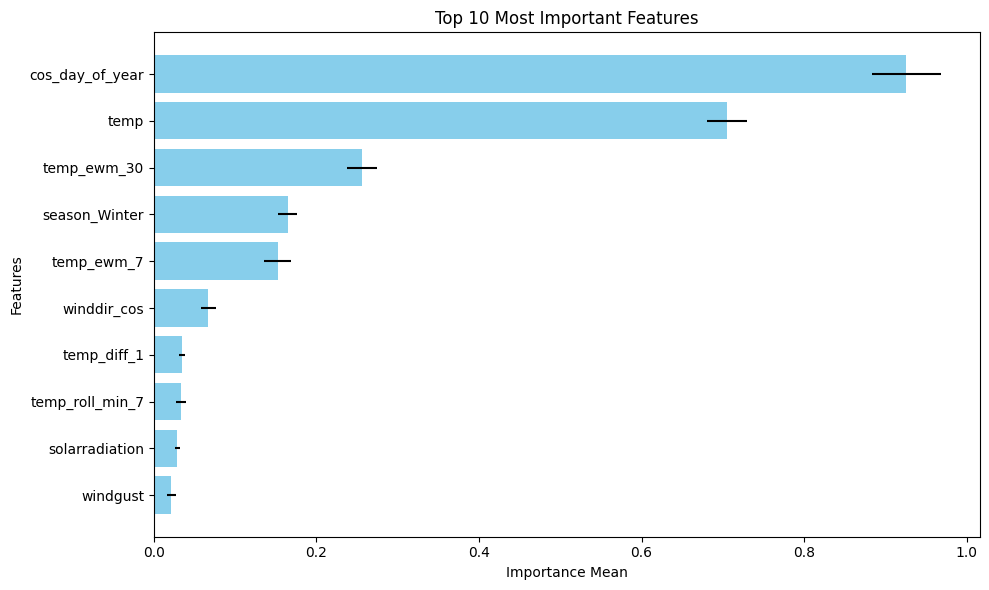

In [48]:
# Import necessary library
import matplotlib.pyplot as plt

# Filter the top 10 features
top_10_features = permutation_importance_df.head(10)

# Plot the top 10 features
plt.figure(figsize=(10, 6))
plt.barh(top_10_features['Feature'], top_10_features['Importance_Mean'], xerr=top_10_features['Importance_Std'], color='skyblue')
plt.xlabel('Importance Mean')
plt.ylabel('Features')
plt.title('Top 10 Most Important Features')
plt.gca().invert_yaxis()  # Invert y-axis to show the most important feature at the top
plt.tight_layout()
plt.show()